# Tutorial 1: Hardware-aware neural architecture search on MNIST

This notebook runs the complete SNAC-Pack pipeline end to end on the MNIST
handwritten-digit dataset.

| Step | Description |
|---|---|
| 1 | Load and visualize the dataset |
| 2 | Run a hardware-aware global search using NSGA-II and the `rule4ml` surrogate |
| 3 | Examine the Pareto front: accuracy versus chip cost |
| 4 | Compress the best architecture with QAT and iterative magnitude pruning |
| 5 | (Extension) Search over Conv and ConvAttn block types |

All search parameters are controlled by `t1_config.yaml` in this directory.
The slides cover the motivation and theory behind each stage; this notebook
implements the pipeline.

In [1]:
!which python

/opt/miniconda3/envs/snac-pack-refactor/bin/python


In [2]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent          # repo root
sys.path.insert(0, str(ROOT))

import yaml
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from utils.tf_global_search import GlobalSearchTF
from utils.tf_local_search_separated import local_search_entrypoint
from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_visualization import plot_pareto_fronts, plot_interactive_2d_pareto

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
print('TensorFlow:', tf.__version__)

cfg     = yaml.safe_load(open(Path.cwd() / 't1_config.yaml'))
ds_cfg  = cfg['dataset']
s_cfg   = cfg['search']
ss_cfg  = cfg['search_space']
ls_cfg  = cfg['local_search']
out_cfg = cfg['output']

RESULTS_DIR = out_cfg['results_dir']
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir  : {RESULTS_DIR}')
print(f'n_trials={s_cfg["n_trials"]}, epochs={s_cfg["epochs"]}, hw_metrics={s_cfg["use_hardware_metrics"]}')

2026-05-22 21:18:48.014762: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.15.1
Results dir  : ./results/tutorial1_mlp
n_trials=20, epochs=5, hw_metrics=True


## The codesign premise

Every architectural choice (layer count, width, activation function, quantization
precision) affects accuracy, chip area (LUTs, DSPs, BRAM), and inference latency
simultaneously (slide 3).
Traditional NAS optimizes accuracy and evaluates hardware cost only at the end.
SNAC-Pack incorporates hardware cost directly as a search objective, producing a
Pareto set of architectures rather than a single answer.

<details>
<summary>Background: machine learning</summary>

A neural network is a parameterised function composed of layers of multiply-accumulate
operations. Training adjusts the weight parameters so that the network maps each input
(e.g. a digit image) to the correct output label (0-9).
The term *architecture* refers to the network's shape: depth, layer widths, and
activation functions.

</details>

<details>
<summary>Background: FPGAs and resource metrics</summary>

An FPGA (Field-Programmable Gate Array) is a chip whose logic fabric is configured at
run time. Unlike a GPU, it has no fixed multiply-accumulate units; arithmetic is
synthesised from LUTs (look-up tables) and DSPs (fast multiplier blocks).
Smaller networks consume fewer LUTs and DSPs, allowing deployment on smaller and
lower-power devices.
hls4ml translates a trained Keras model into HLS C++, which Vivado then synthesises to
an FPGA bitstream.

</details>


## Dataset: MNIST

Each sample is a greyscale image of a handwritten digit (0-9), resized to 8x8
pixels and flattened to a 64-dimensional vector for MLP input.

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (200, 8, 8, 1), x_val shape: (200, 8, 8, 1)
  y_train shape: (200,), y_val shape: (200,)


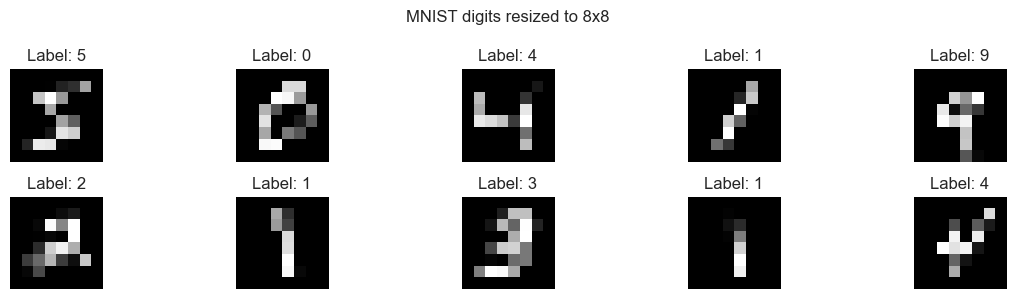

In [3]:
x_viz, y_viz, _, _ = load_and_preprocess_mnist(
    resize_val=ds_cfg['resize_val'],
    subset_size=200,
    flatten=False,
    one_hot=False,
)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_viz[i].squeeze(), cmap='gray')
    plt.title(f'Label: {y_viz[i]}')
    plt.axis('off')
plt.suptitle(f'MNIST digits resized to {ds_cfg["resize_val"]}x{ds_cfg["resize_val"]}')
plt.tight_layout()
plt.show()

## The configuration file

SNAC-Pack is entirely config-driven (slide 17).
The table below maps each YAML block to the corresponding slide.

| Block | Controls | Slide |
|---|---|---|
| `dataset` | Task, resize, subset size | 17 |
| `search` | Trial budget, objectives, surrogate on/off | 8, 14 |
| `search_space` | Layer types, widths, activations | 18 |
| `hls_config` | Target FPGA board, precision, reuse factor | 16-17 |
| `local_search` | QAT precision pairs, pruning schedule | 9-11 |

The cell below prints the file you are about to run.

In [4]:
with open(Path.cwd() / 't1_config.yaml') as fh:
    print(fh.read())

# Tutorial 1-v2: Hardware-aware MLP search on MNIST
# ===================================================
# Surrogate ON: 4 objectives (accuracy, BOPs, avg FPGA resources, clock cycles).
# Kept small for live demos — n_trials=8, epochs=3, subset_size=10000.
#
# NOTE: rule4ml (hardware metrics) needs the conda library path at runtime:
#   export LD_LIBRARY_PATH="$CONDA_PREFIX/lib:${LD_LIBRARY_PATH:-}"

dataset:
  name: mnist
  resize_val: 8
  subset_size: 10000
  flatten: true
  one_hot: true

search:
  model_type: mlp
  n_trials: 20
  epochs: 5
  use_hardware_metrics: true
  objective_names: [performance_metric, bops, avg_resource, clock_cycles]
  maximize_flags: [true, false, false, false]

search_space:
  mlp_width_space: [8, 16, 32, 64, 128]
  act_space: [relu, tanh, sigmoid]
  norm_space: [null, batch]
  block_types: [MLP]
  num_blocks: 3
  initial_img_size: 8
  output_dim: 10
  output_activation: softmax
  # Required dummy keys (validator demands them even for MLP-only searches):


## Fixed-point quantization (slide 10)

On FPGAs, weights are represented as fixed-point numbers `ap_fixed<W, I>`,
where W is the total bit-width and I is the number of integer bits.
Reducing W shrinks the multipliers and lowers resource cost;
too few bits introduces rounding error and degrades accuracy.
Quantization-aware training (QAT) recovers accuracy by simulating the rounding
during the training forward pass.

The cell below shows how a single weight value is approximated at several precisions.
Use the slider to vary the maximum bit-width displayed.

In [5]:
_PRECISIONS = [
    ('FP32',           32, 0.72341),
    ('ap_fixed<16,6>', 16, 0.72363),
    ('ap_fixed<8,3>',   8, 0.71875),
    ('ap_fixed<6,2>',   6, 0.71875),
    ('ap_fixed<4,1>',   4, 0.75000),
]

def _show_quant_table(max_bits):
    fp32_val = _PRECISIONS[0][2]
    header = f'{"Format":<20}{"Bits":>6}{"Value":>12}{"Rounding error":>18}'
    print(header)
    print('-' * len(header))
    for name, bits, val in _PRECISIONS:
        if bits <= max_bits:
            err = abs(val - fp32_val)
            print(f'{name:<20}{bits:>6}{val:>12.5f}{err:>18.5f}')

try:
    import ipywidgets as widgets
    widgets.interact(
        _show_quant_table,
        max_bits=widgets.SelectionSlider(
            options=[4, 6, 8, 16, 32],
            value=32,
            description='Max bits:',
            style={'description_width': 'initial'},
        ),
    )
except ImportError:
    _show_quant_table(32)

interactive(children=(SelectionSlider(description='Max bits:', index=4, options=(4, 6, 8, 16, 32), style=Slide…

## Stage 1: Global search with hardware surrogate

NSGA-II samples candidate architectures, trains each briefly, then calls `rule4ml`
to estimate LUT%, DSP%, BRAM%, and clock cycles without running Vivado
(milliseconds per trial rather than hours).
Non-dominated solutions advance to the next generation; the final output is a
Pareto front.

<details>
<summary>Background: avg_resource and clock_cycles</summary>

`avg_resource` is the arithmetic mean of the LUT%, DSP%, BRAM%, and FF% estimates
returned by `rule4ml`. A lower value indicates a more resource-efficient model.
`clock_cycles` is the predicted inference latency in clock cycles at the configured
clock frequency. At 250 MHz, 10 cycles corresponds to approximately 40 ns.

</details>

In [6]:
obj_names = s_cfg['objective_names']
max_flags = s_cfg['maximize_flags']

searcher = GlobalSearchTF(
    search_space_path=ss_cfg,
    results_dir=RESULTS_DIR,
)

study = searcher.run_search(
    model_type=s_cfg['model_type'],
    n_trials=s_cfg['n_trials'],
    epochs=s_cfg['epochs'],
    dataset=ds_cfg['name'],
    subset_size=ds_cfg['subset_size'],
    resize_val=ds_cfg['resize_val'],
    objectives=obj_names,
    maximize_flags=max_flags,
    use_hardware_metrics=s_cfg['use_hardware_metrics'],
)

print('Global search complete.')


Starting MLP Global Search on MNIST



[I 2026-05-22 21:18:52,990] A new study created in memory with name: no-name-94fc6c66-b1d3-40e6-92d8-d98d1bebe63b


Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)
Using in-memory Optuna study (single-node mode)


[I 2026-05-22 21:19:03,784] Trial 0 finished with values: [0.8464999794960022, 10332352.0, 2.485, 170.18] and parameters: {'num_layers': 2, 'hidden_units_0': 128, 'activation_0': 'tanh', 'normalization_0': 'batch'}.


Trial 0: Accuracy=0.8465, BOPs=10332352.0


...

Trial 17: Accuracy=0.7368, BOPs=5658688.0


[I 2026-05-22 21:20:44,516] Trial 18 finished with values: [0.7853999733924866, 2584128.0, 0.7599999999999999, 87.12] and parameters: {'num_layers': 2, 'hidden_units_0': 32, 'activation_0': 'sigmoid', 'normalization_0': 'batch'}.


Trial 18: Accuracy=0.7854, BOPs=2584128.0


[I 2026-05-22 21:20:51,258] Trial 19 finished with values: [0.8072999715805054, 7410880.0, 2.5250000000000004, 136.94] and parameters: {'num_layers': 5, 'hidden_units_0': 16, 'activation_0': 'tanh', 'normalization_0': 'batch', 'hidden_units_1': 8, 'activation_1': 'tanh', 'normalization_1': 'batch', 'hidden_units_2': 32, 'activation_2': 'tanh', 'normalization_2': None, 'hidden_units_3': 128, 'activation_3': 'tanh', 'normalization_3': None}.


Trial 19: Accuracy=0.8073, BOPs=7410880.0

CSV results saved to ./results/tutorial1_mlp/mlp_search_results.csv (20 trials)

🏆 Best model architecture (Trial 9) saved for local search:
   - Source: ./results/tutorial1_mlp/trial_yamls/trial_9_arch.yaml
   - Destination: ./results/tutorial1_mlp/best_model_for_local_search.yaml
   - Accuracy: 0.8888
2D Pareto fronts plot saved to ./results/tutorial1_mlp/pareto_fronts_2d.png
3D Pareto front plot saved to ./results/tutorial1_mlp/pareto_front_3d.html

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 1):
  Values: {'performance_metric': 0.8180000185966492, 'bops': 2584128.0, 'avg_resource': 0.7525, 'clock_cycles': 87.23}
  Params: {'num_layers': 2, 'hidden_units_0': 32, 'activation_0': 'tanh', 'normalization_0': 'batch'}

Rank 2 (Trial 5):
  Values: {'performance_metric': 0.8471999764442444, 'bops': 11625216.0, 'avg_resource': 3.7749999999999995, 'clock_cycles': 41.53}
  Params: {'num_layers': 4, 'hidden_units_0': 128, 'activation_0': 'tanh', 'norma

## Pareto front analysis

The search returns a set of Pareto-optimal architectures, not a single best model
(slide 5/15).
Each point on the front represents a genuine trade-off; the choice of which model
to use depends on the application's resource and latency budget.
Hovering over a point in the interactive plot displays the full architecture
description for that trial.

Highest-accuracy trial : 9  Accuracy : 0.8888  BOPs : 1.38e+07
Pareto plots saved to  : ./results/tutorial1_mlp


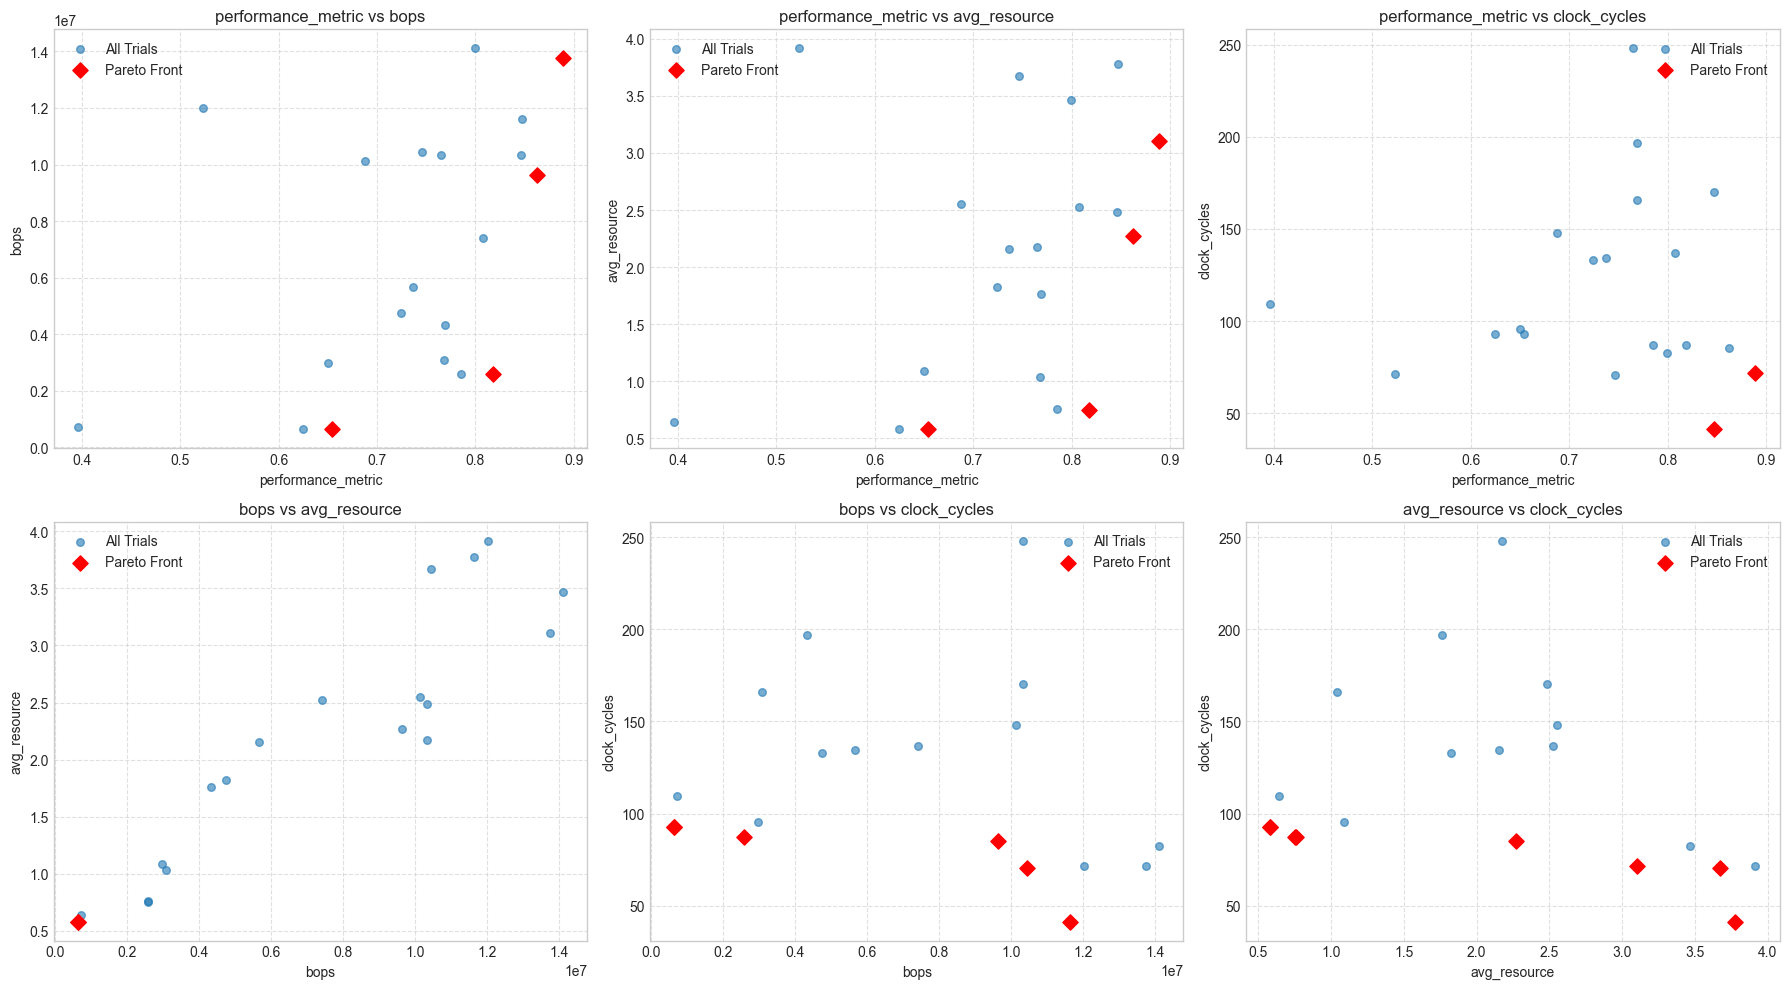

2D Pareto fronts plot saved to ./results/tutorial1_mlp/pareto_fronts_2d.png


Interactive 2D Pareto front plot saved to ./results/tutorial1_mlp/interactive_pareto_front_2d.html


In [7]:
results_df = pd.DataFrame(searcher.results)

if not results_df.empty:
    best = results_df.loc[results_df['performance_metric'].idxmax()]
    print(f'Highest-accuracy trial : {int(best["trial"])}  '
          f'Accuracy : {best["performance_metric"]:.4f}  '
          f'BOPs : {best["bops"]:.2e}')
    print(f'Pareto plots saved to  : {RESULTS_DIR}')

    obj_info = list(zip(obj_names, max_flags))
    plot_pareto_fronts(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
    plot_interactive_2d_pareto(results_df, obj_info, save_dir=RESULTS_DIR, show=True)
else:
    print('No results available. Run the global search cell above first.')

## Exercise: modify the search and observe the effect

Before running the cell below, consider the following question:

Does a wide, shallow network (e.g. two layers of 128 neurons) consume more or fewer
LUTs than a narrow, deep network (e.g. six layers of 16 neurons)?
Modify the parameters, re-run the global search cell, and examine how the Pareto
front shifts.

This exercise illustrates the central principle: **SNAC-Pack is controlled entirely
through the YAML configuration**.

In [8]:
# Modify these values, then re-run the 'Stage 1: Global search' cell above.

cfg['search']['n_trials'] = 5                          # suggested range: 3-10
cfg['search_space']['mlp_width_space'] = [8, 32, 128]  # try [8, 16] or [64, 128, 256]

# To disable the hardware surrogate and optimize accuracy alone, uncomment:
# cfg['search']['use_hardware_metrics'] = False

# Refresh shorthand references so GlobalSearchTF picks up the changes.
s_cfg     = cfg['search']
ss_cfg    = cfg['search_space']
obj_names = s_cfg['objective_names']
max_flags = s_cfg['maximize_flags']

print('Configuration updated.')
print(f'  n_trials   : {s_cfg["n_trials"]}')
print(f'  widths     : {ss_cfg["mlp_width_space"]}')
print(f'  hw_metrics : {s_cfg["use_hardware_metrics"]}')
print()
print('Re-run the "Stage 1: Global search" cell to apply.')

Configuration updated.
  n_trials   : 5
  widths     : [8, 32, 128]
  hw_metrics : True

Re-run the "Stage 1: Global search" cell to apply.


## Stage 2: Local search: quantization and pruning

The global search determines the architecture shape.
Local search compresses the selected model using two techniques.

**Quantization-aware training (QAT)** retrains the model while simulating
fixed-point rounding in the forward pass, so the network learns to tolerate the
precision loss. The search sweeps all `precision_pairs` specified in the config
(slides 10, 11).

**Iterative magnitude pruning** ranks weights by absolute value, zeros the smallest
fraction, and retrains to recover accuracy. This is repeated for several iterations.
Typical results: 70-95% sparsity with less than 1% accuracy degradation (slide 11).

In [9]:
# Reload the original config to ensure local search parameters are unaffected
# by any modifications made in the Exercise cell above.
cfg_orig    = yaml.safe_load(open(Path.cwd() / 't1_config.yaml'))
ds_cfg_orig = cfg_orig['dataset']
ls_cfg_orig = cfg_orig['local_search']
RESULTS_DIR = cfg_orig['output']['results_dir']

LOCAL_RESULTS_DIR = os.path.join(RESULTS_DIR, 'local_search_separated')
LOCAL_CONFIG_PATH = os.path.join(RESULTS_DIR, 'local_search_config.yaml')
ARCH_YAML_PATH    = os.path.join(RESULTS_DIR, 'best_model_for_local_search.yaml')

local_search_settings = {
    'pruning_settings': {
        'iterations':           ls_cfg_orig['pruning_iterations'],
        'epochs_per_iteration': ls_cfg_orig['pruning_epochs'],
        'pruning_rate':         ls_cfg_orig['pruning_rate'],
    },
    'qat_settings': {
        'epochs':          ls_cfg_orig['qat_epochs'],
        'precision_pairs': ls_cfg_orig['precision_pairs'],
    },
}
with open(LOCAL_CONFIG_PATH, 'w') as fh:
    yaml.dump(local_search_settings, fh)

x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=ds_cfg_orig['resize_val'],
    subset_size=ds_cfg_orig['subset_size'],
    flatten=True,
    one_hot=True,
)

if os.path.exists(ARCH_YAML_PATH):
    pruning_df, qat_df = local_search_entrypoint(
        architecture_yaml_path=ARCH_YAML_PATH,
        local_search_config_path=LOCAL_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_RESULTS_DIR,
    )
else:
    print(f'Architecture YAML not found: {ARCH_YAML_PATH}')
    print('Complete the global search first, then return to this cell.')
    pruning_df, qat_df = pd.DataFrame(), pd.DataFrame()

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)

 STARTING SEPARATED LOCAL SEARCH STAGE 

--- FP32 pretraining (20 epochs, lr=0.001) ---
Epoch 1/20
79/79 [==============================] - 1s 5ms/step - loss: 1.3724 - accuracy: 0.6021 - val_loss: 1.6301 - val_accuracy: 0.7298
Epoch 2/20
79/79 [==============================] - 0s 3ms/step - loss: 0.7253 - accuracy: 0.8241 - val_loss: 1.1723 - val_accuracy: 0.7964
Epoch 3/20
79/79 [==============================] - 0s 3ms/step - loss: 0.5251 - accuracy: 0.8623 - val_loss: 0.7852 - val_accuracy: 0.8467
Epoch 4/20
79/79 [==============================] - 0s 3ms/step - loss: 0.4271 - accuracy: 0.8826 - val_loss: 0.5465 - val_accuracy: 0.8734
Epoch 5/20
79/79 [==============================] - 0s 3ms/step - loss: 0.3602 - accuracy: 0.9007 - val_loss: 0.4262 - val_accuracy: 0.8866
Epoch 6/20
79/79 [==============================] - 0s 3m

/opt/miniconda3/envs/snac-pack-refactor/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning:

The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.



79/79 [==============================] - 2s 8ms/step - loss: 1.5815 - accuracy: 0.5546 - val_loss: 1.9169 - val_accuracy: 0.5061
Epoch 2/3
79/79 [==============================] - 0s 4ms/step - loss: 1.2012 - accuracy: 0.6389 - val_loss: 1.2078 - val_accuracy: 0.6412
Epoch 3/3
79/79 [==============================] - 0s 3ms/step - loss: 1.0026 - accuracy: 0.7025 - val_loss: 0.9835 - val_accuracy: 0.7071
  -> Final accuracy for precision <4,1>: 0.7071

 SEPARATED LOCAL SEARCH COMPLETE 


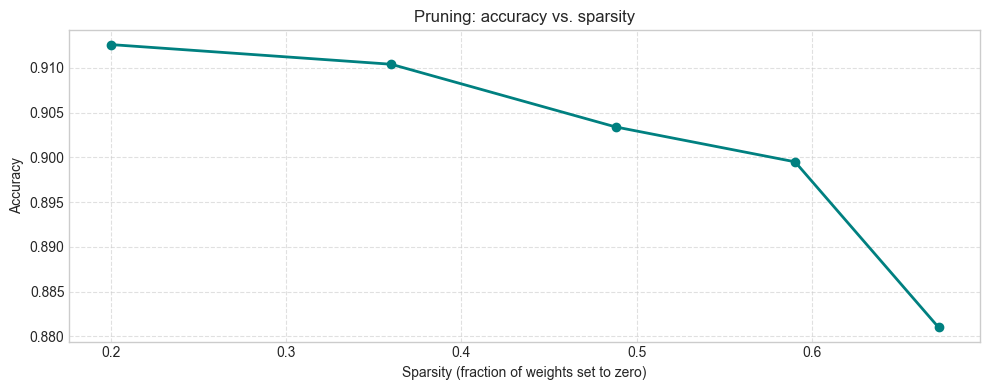

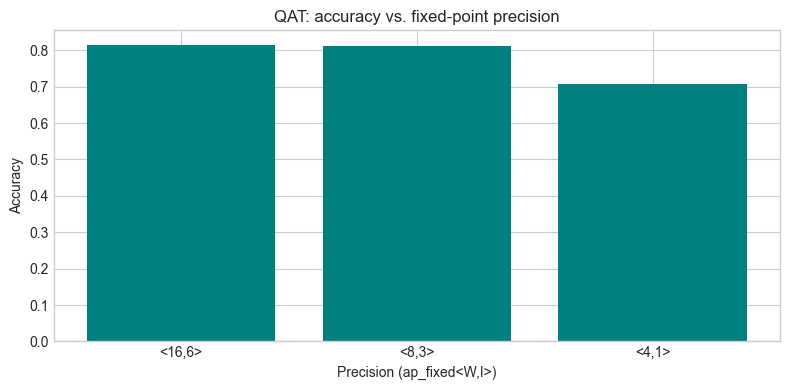

In [10]:
if not pruning_df.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(pruning_df['Sparsity'], pruning_df['Accuracy'],
             marker='o', linewidth=2, color='teal')
    plt.title('Pruning: accuracy vs. sparsity')
    plt.xlabel('Sparsity (fraction of weights set to zero)')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if not qat_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(qat_df)), qat_df['Accuracy'],
            tick_label=qat_df['Precision'], color='teal')
    plt.title('QAT: accuracy vs. fixed-point precision')
    plt.xlabel('Precision (ap_fixed<W,I>)')
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

## Pruning visualization

The slider below shows how the weight matrix changes as the sparsity level increases.
Active weights are shown as filled cells; pruned weights are blank.
The right panel marks the current sparsity level on the accuracy curve from the local
search above.

In [11]:
_rng = np.random.default_rng(42)
_W   = _rng.random((10, 10))

_spar_vals = pruning_df['Sparsity'].tolist() if not pruning_df.empty else []
_acc_vals  = pruning_df['Accuracy'].tolist() if not pruning_df.empty else []

def _show_pruning(sparsity_pct):
    sparsity = sparsity_pct / 100.0
    mask     = _rng.random((10, 10)) > sparsity
    sparse_W = _W * mask
    n_active = int(mask.sum())

    ncols = 3 if _spar_vals else 2
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3.5))

    axes[0].imshow(_W > 0, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('Dense  (100 weights active)')
    axes[0].axis('off')

    axes[1].imshow(sparse_W != 0, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title(f'Sparse  ({n_active}/100 active)')
    axes[1].axis('off')

    if _spar_vals:
        axes[2].plot(_spar_vals, _acc_vals, 'o-', color='teal', linewidth=2)
        axes[2].axvline(x=sparsity, color='red', linestyle='--',
                        label=f'{sparsity_pct}% zeroed')
        axes[2].set(xlabel='Sparsity', ylabel='Accuracy',
                    title='Accuracy vs. sparsity')
        axes[2].legend()
        axes[2].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'Sparsity = {sparsity_pct}%', fontsize=13)
    plt.tight_layout()
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        _show_pruning,
        sparsity_pct=widgets.IntSlider(
            min=0, max=90, step=10, value=0,
            description='Sparsity %:',
            style={'description_width': 'initial'},
        ),
    )
except ImportError:
    _show_pruning(0)

interactive(children=(IntSlider(value=0, description='Sparsity %:', max=90, step=10, style=SliderStyle(descrip…

---
## Extension: searching over convolutional and attention blocks

The search space supports four block types: **Conv**, **ConvAttn**, **MLP**, and
**None** (identity skip). Modern architectures including self-attention blocks are
therefore fully searchable.

**Why is the hardware surrogate disabled for this extension?**
`rule4ml` estimates resources only for networks with ReLU, Softmax, and linear
activations; it also flattens models before evaluation, which removes the spatial
structure that convolutional and attention blocks require.
With `use_hardware_metrics: false`, SNAC-Pack searches the full block space but
optimizes accuracy alone, hardware cost is not included in the search objective.

This is an explicit trade-off: one toggle (`use_hardware_metrics`) and one
`block_types` entry separate hardware-aware codesign from unconstrained architecture
exploration.

This cell loads `t1_conv_config.yaml`, which configures a Conv/ConvAttn/MLP/None
block search on MNIST with the hardware surrogate disabled.

In [12]:
conv_cfg     = yaml.safe_load(open(Path.cwd() / 't1_conv_config.yaml'))
conv_ds_cfg  = conv_cfg['dataset']
conv_s_cfg   = conv_cfg['search']
conv_ss_cfg  = conv_cfg['search_space']
conv_out_cfg = conv_cfg['output']

CONV_RESULTS_DIR = conv_out_cfg['results_dir']
os.makedirs(CONV_RESULTS_DIR, exist_ok=True)

conv_obj_names = conv_s_cfg['objective_names']
conv_max_flags = conv_s_cfg['maximize_flags']

print(f'Block types       : {conv_ss_cfg["block_types"]}')
print(f'Hardware metrics  : {conv_s_cfg["use_hardware_metrics"]}  (surrogate disabled)')
print(f'n_trials          : {conv_s_cfg["n_trials"]}')
print()

conv_searcher = GlobalSearchTF(
    search_space_path=conv_ss_cfg,
    results_dir=CONV_RESULTS_DIR,
)

conv_study = conv_searcher.run_search(
    model_type=conv_s_cfg['model_type'],
    n_trials=conv_s_cfg['n_trials'],
    epochs=conv_s_cfg['epochs'],
    dataset=conv_ds_cfg['name'],
    subset_size=conv_ds_cfg['subset_size'],
    resize_val=conv_ds_cfg['resize_val'],
    objectives=conv_obj_names,
    maximize_flags=conv_max_flags,
    use_hardware_metrics=conv_s_cfg['use_hardware_metrics'],
    n_folds=conv_s_cfg.get('n_folds', 1),
)
print('Block search complete.')

Block types       : ['Conv', 'ConvAttn', 'MLP', 'None']
Hardware metrics  : False  (surrogate disabled)
n_trials          : 20


Starting BLOCK Global Search on MNIST



[I 2026-05-22 21:21:29,776] A new study created in memory with name: no-name-77b89e1e-9809-4303-a88c-41932021e34b


Data loaded and preprocessed:
  Resize: 16x16
  x_train shape: (5000, 16, 16, 1), x_val shape: (5000, 16, 16, 1)
  y_train shape: (5000,), y_val shape: (5000,)
Using in-memory Optuna study (single-node mode)


[I 2026-05-22 21:21:31,484] Trial 0 finished with values: [0.7919999957084656, 11698176.0] and parameters: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'Conv', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 0: Accuracy=0.7920, BOPs=11698176


...

Trial 17: Accuracy=0.1846, BOPs=105021440


[I 2026-05-22 21:23:14,760] Trial 18 finished with values: [0.29159998893737793, 67469312.0] and parameters: {'b0': 'None', 'b1': 'None', 'b2': 'Conv', 'b3': 'MLP', 'b2_Conv_channels_0': 1, 'b2_Conv_channels_1': 1, 'b2_Conv_kernels_0': 3, 'b2_Conv_kernels_1': 3, 'b2_Conv_acts_0': 'GELU', 'b2_Conv_acts_1': 'GELU', 'b2_Conv_norms_0': None, 'b2_Conv_norms_1': 'batch', 'b3_MLP_units': 0, 'b3_MLP_act': 'LeakyRelu', 'b3_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'LeakyRelu', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': 'batch'}.


Trial 18: Accuracy=0.2916, BOPs=67469312


[I 2026-05-22 21:23:16,413] Trial 19 finished with values: [0.8059999942779541, 5406720.0] and parameters: {'b0': 'MLP', 'b1': 'ConvAttn', 'b2': 'Conv', 'b3': 'None', 'b0_MLP_units': 0, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': 'batch'}.


Trial 19: Accuracy=0.8060, BOPs=5406720

CSV results saved to ./results/tutorial1_conv/block_search_results.csv (20 trials)

🏆 Best model architecture (Trial 13) saved for local search:
   - Source: ./results/tutorial1_conv/trial_yamls/trial_13_arch.yaml
   - Destination: ./results/tutorial1_conv/best_model_for_local_search.yaml
   - Accuracy: 0.9306
2D Pareto fronts plot saved to ./results/tutorial1_conv/pareto_fronts_2d.png

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 1):
  Values: {'performance_metric': 0.8356000185012817, 'bops': 13959168.0}
  Params: {'b0': 'MLP', 'b1': 'Conv', 'b2': 'MLP', 'b3': 'ConvAttn', 'b0_MLP_units': 1, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': None, 'b2_MLP_units': 1, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': 'batch', 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'LeakyRelu', 'MLP_Head_acts_1': 'LeakyRelu', 'MLP_Head_acts_2': 'ReLU', 'MLP_Head_norms_0': 'batch', 'MLP_Head_norms_1': 'batch', 'MLP_Head_norms_2': None}

Rank 2 (Trial 2):
  Values: {'p

Best trial   : 13
Accuracy     : 0.9306
BOPs         : 9.56e+07



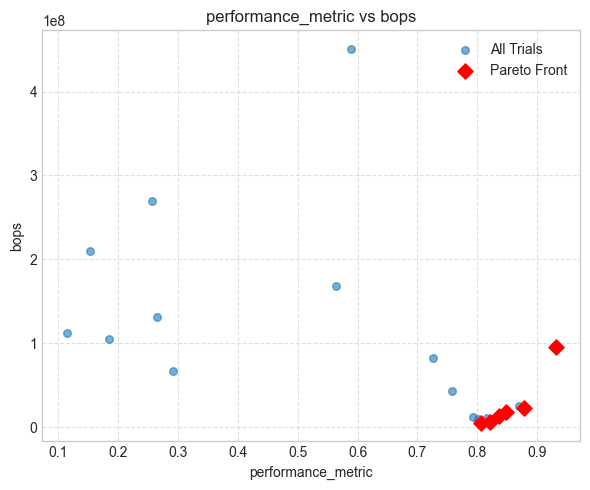

2D Pareto fronts plot saved to ./results/tutorial1_conv/pareto_fronts_2d.png


In [13]:
conv_results_df = pd.DataFrame(conv_searcher.results)
if not conv_results_df.empty:
    best_conv = conv_results_df.loc[conv_results_df['performance_metric'].idxmax()]
    print(f'Best trial   : {int(best_conv["trial"])}')
    print(f'Accuracy     : {best_conv["performance_metric"]:.4f}')
    print(f'BOPs         : {best_conv["bops"]:.2e}')
    print()

    block_cols = [c for c in conv_results_df.columns if 'block' in c and 'type' in c]
    if block_cols:
        top = conv_results_df.nlargest(min(5, len(conv_results_df)), 'performance_metric')
        print('Top trials and their selected block types:')
        print(top[['trial', 'performance_metric', 'bops'] + block_cols].to_string(index=False))
        print()

    conv_obj_info = list(zip(conv_obj_names, conv_max_flags))
    plot_pareto_fronts(conv_results_df, conv_obj_info, save_dir=CONV_RESULTS_DIR, show=True)
else:
    print('No results available. Run the block search cell above first.')

## Summary

| Stage | Description |
|---|---|
| Global search (surrogate enabled) | NSGA-II over MLP architectures; `rule4ml` estimates chip cost per trial |
| Pareto front | Set of accuracy-resource trade-offs; model selection depends on application budget |
| Local search | Best architecture compressed with QAT and iterative magnitude pruning |
| Extension (surrogate disabled) | Same pipeline applied to Conv/ConvAttn block space |

Tutorial 2 applies this pipeline to particle jet data with a latency
constraint, and concludes with hls4ml synthesis to FPGA hardware description code.